In [1]:
import sys
sys.path.append('../src/')
from xpcs import *
from sims import *
from autocorrelations import *
import cv2
from scipy.special import erfinv
import pyopencl as cl
from pathlib import Path
import matplotlib.cm as cm
import json
import matplotlib.ticker as ticker
from cmcrameri import cm
import numpy.ma as ma


%matplotlib notebook

In [2]:
def reciprocal_space_map(lambDuh,tth,hor0,ver0,pix,sam2det,detShape,geometry):
    # Written by Vanya-GPT
    #lambDuh: beam wavelength [Å]
    #tth: detector angle posistion
    #hor0: horizontal beam position
    #ver0: vertical beam position
    #pix: pixel size [mm]
    #sam2det: sample to detector distance [mm]
    #detShape: 2x2 horizontal, vertical
    
    if geometry == 'Horizontal':
        HorScattAngle=tth-np.arctan((np.arange(detShape[0,0],detShape[0,1]+1,1)-hor0)*pix/sam2det)*(180/np.pi); #In degrees
        VerScattAngle=-1*np.arctan((np.arange(detShape[1,0],detShape[1,1]+1,1)-ver0)*pix/sam2det)*(180/np.pi); #In degrees
    if geometry == 'Vertical':
        VerScattAngle=tth-np.arctan((np.arange(detShape[1,0],detShape[1,1]+1,1)-ver0)*pix/sam2det)*(180/np.pi); #In degrees
        HorScattAngle=-1*np.arctan((np.arange(detShape[0,0],detShape[0,1]+1,1)-hor0)*pix/sam2det)*(180/np.pi); #In degrees
    if geometry != 'Horizontal' and geometry != 'Vertical':
        sys.exit(f"Geometry must be either Vertical or Horizontal.")
        
    qx=(4*np.pi/lambDuh)*np.sin((HorScattAngle/2)*np.pi/180); # [Å^-1]
    qy=(4*np.pi/lambDuh)*np.sin((VerScattAngle/2)*np.pi/180); # [Å^-1]
    
    return qx,qy

In [3]:
CONFIG_FILE_NAME = "NPS_11092023_processed_config.json"

figure_path = '/Users/eriklamb/Documents/Publications/NPS_Petra/Figures/'

In [4]:
# Define the path to the configuration file
config_path = Path("/Users/eriklamb/Documents/Python/Projects/XPCS/configs/"+CONFIG_FILE_NAME)

# Open and load the JSON configuration file
with open(config_path, "r") as file:
    config = json.load(file)
    #json_str = json.loads(jsonString, strict=False)

In [5]:
temps = np.array([298,305,325,345,365,385,405,350])
#temps = np.array([298,345,385,405,350])
#temps = np.array([298])

<IPython.core.display.Javascript object>


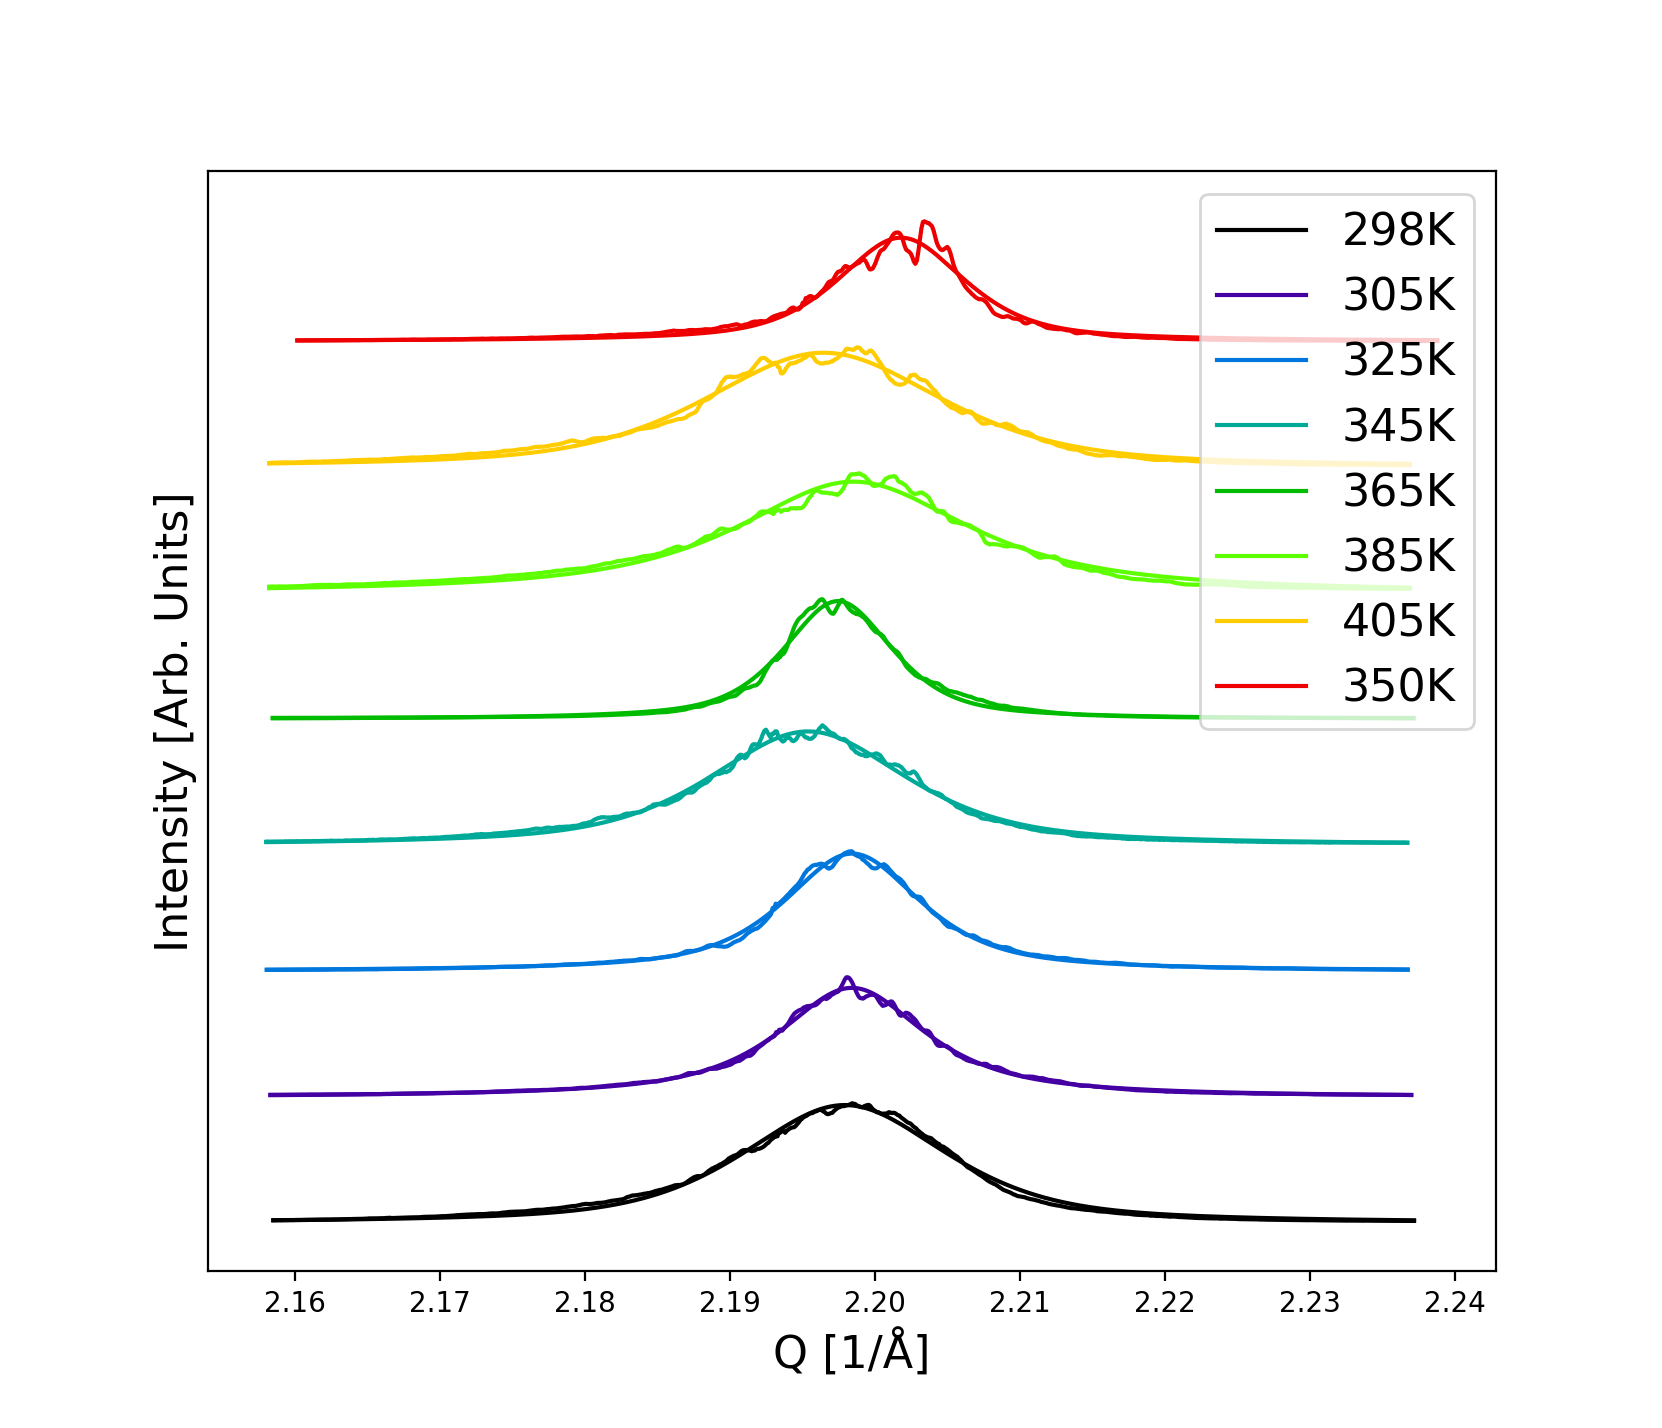

<IPython.core.display.Javascript object>


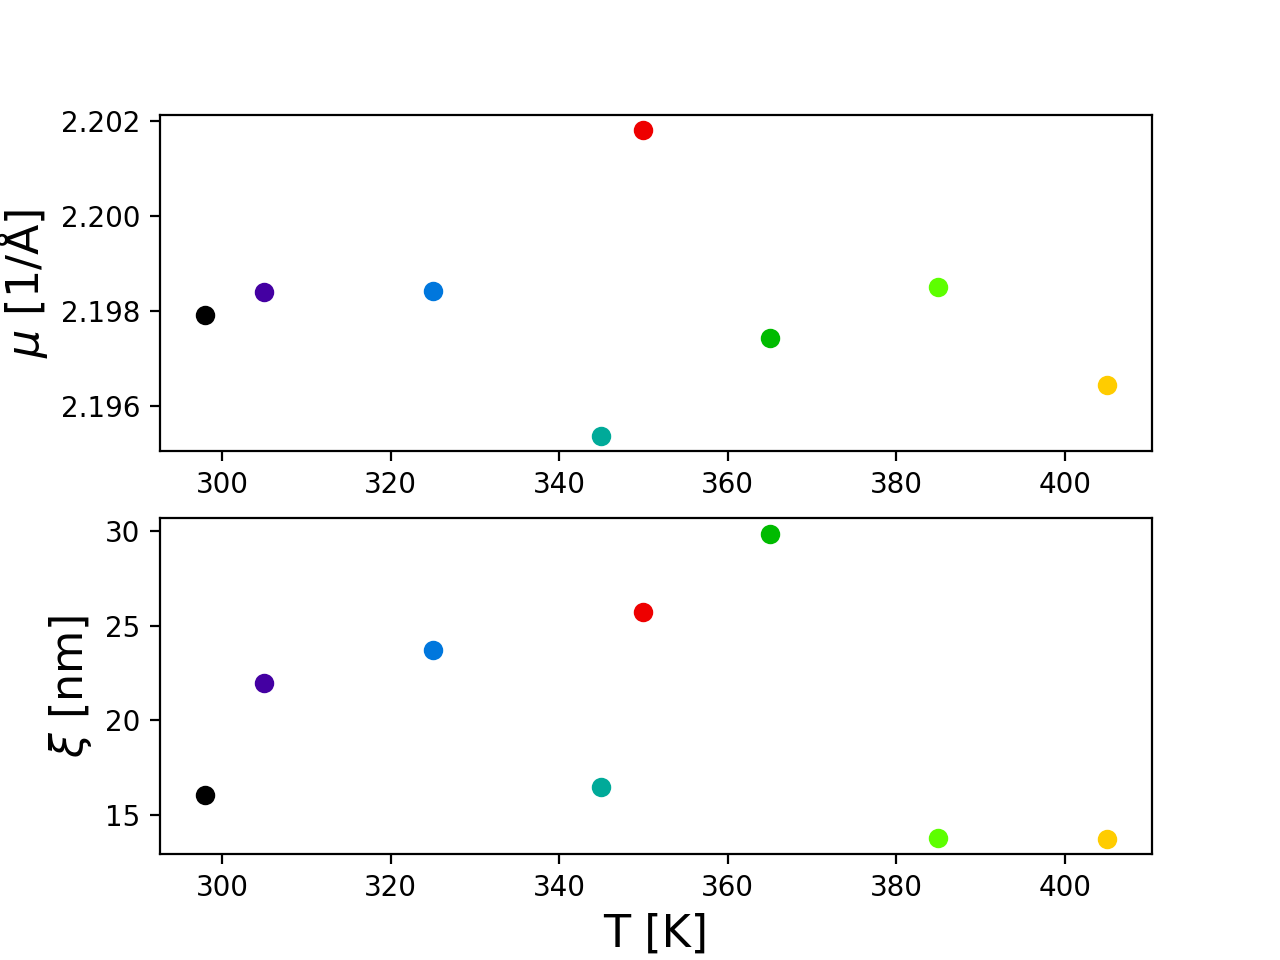

/var/folders/wg/d6rgw7nd3p9gs4wz8ngmmpj00000gn/T/ipykernel_10429/4097016640.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('nipy_spectral', len(temps)+1)


Temeperature=298: vCen = 780, hCen = 1514
[260, 1300, 1139, 1889]
7955.311849515755
8.910713452078898
Temeperature=305: vCen = 1401, hCen = 1506
[811, 1851, 1139, 1889]
5555.128086607848
8.91271126472236
Temeperature=325: vCen = 1368, hCen = 1504
[811, 1851, 1139, 1889]
6214.076556362908
8.912804738750921
Temeperature=345: vCen = 734, hCen = 1536
[260, 1300, 1139, 1889]
2305.487611772059
8.90036679539704
Temeperature=365: vCen = 1420, hCen = 1517
[811, 1851, 1139, 1889]
6025.322017002592
8.908766217497693
Temeperature=385: vCen = 1276, hCen = 1519
[811, 1851, 1139, 1889]
8468.21516745462
8.913165148676116
Temeperature=405: vCen = 1293, hCen = 1535
[811, 1851, 1139, 1889]
7145.611750009874
8.904714367361372
Temeperature=350: vCen = 712, hCen = 1493
[260, 1300, 1139, 1889]
4367.950305547791
8.926575262890534


In [14]:
bar_shift = np.array([384,314,347,430,295,439,422,452])
fig,ax = plt.subplots()
fig2,ax2 = plt.subplots(2,1)

#colors = create_color_list(temps.shape[0])
#cmap = cm.batlow
cmap = plt.cm.get_cmap('nipy_spectral', len(temps)+1)
colors = cmap(np.linspace(0, 1, len(temps)+1))  # spread evenly across the colormap

i=0
for i, (cc,T) in enumerate(zip(colors,temps)):
    
    # Load Processed and batchinfo
    BASE = Path(config.get("BASE"))
    file_processed = BASE/Path(config.get(f"{T}_processed"))
    file_data = BASE/Path(config.get(f"{T}_data"))

    batchinfo = load_batchinfo(BASE/Path(config.get(f"{T}_batchinfo")),':') # batchinfo contains other parameters

    # Load batchinfo parameters
    ccdz = batchinfo['ccdz']
    ccdz0 = batchinfo['ccdz0']
    
    
    #Load file
    with h5py.File(file_processed, 'r') as DATA:
        #print(DATA.keys())
        
        vCen       = DATA['pre_processing/vCen'][:][0]
        hCen       = DATA['pre_processing/hCen'][:][0]
        
        if T==298:
            #det        = DATA['data/det'][:]

            detDims    = DATA['experimental_parameters/det_dimensions'][:]
            ttheta     = DATA['experimental_parameters/ttheta'][:][0]
            pixelSize  = DATA['experimental_parameters/pixel_size'][:][0]
            D          = DATA['experimental_parameters/sam_to_det'][:][0]
            wavelength = DATA['experimental_parameters/wavelength'][:][0]
            X0         = DATA['experimental_parameters/X0'][:][0]
            Y0         = DATA['experimental_parameters/Y0'][:][0]

            vSig       = DATA['pre_processing/vSig'][:][0]
            hSig       = DATA['pre_processing/hSig'][:][0]
            
            refCen = hCen
            #DETS   = np.zeros((temps.shape[0],det.shape[0],det.shape[1],det.shape[2]))
            #VCENS = np.zeros((1,temps.shape[0]))
            #HCENS = np.zeros((1,temps.shape[0]))
            
            
            
            
            

    print(f'Temeperature={T}: vCen = {vCen}, hCen = {hCen}')

    Xv = 4
    Xh = 5 
    vshift = bar_shift[0]-bar_shift[i]
    #hshift = refCen - hCen
    vCen = vCen - vshift
    #hCen = refCen 
    #roi = [int(vCen-Xv*vSig),int(vCen+Xv*vSig),int(hCen-Xh*hSig),int(hCen+Xh*hSig)]#vertical_1, vertical_2, horizontal_1, horizontal_2
    roi = [int(vCen-Xv*vSig),int(vCen+Xv*vSig),int(refCen-Xh*hSig),int(refCen+Xh*hSig)]
    print(roi)
    
    
    
    with h5py.File(file_data, 'r') as DATA:
        if T==298:
            det    = DATA['entry/data/data_000001/'][:,roi[0]:roi[1],roi[2]:roi[3]]
            DETS   = np.zeros((temps.shape[0],det.shape[0],det.shape[1],det.shape[2]))
            VCENS = np.zeros((1,temps.shape[0]))
            HCENS = np.zeros((1,temps.shape[0]))                        
        if T!=298:
            det        = DATA['entry/data/data_000001/'][:DETS.shape[1],roi[0]:roi[1],roi[2]:roi[3]]
        #Remove hot pixels
        det[det>100] = 0
            
    DETS[i] = det
    VCENS[0,i] = vCen
    HCENS[0,i] = hCen
    
    
    #fig2,ax2 = plt.subplots()
    #ax2.imshow(np.sum(det[0:10,:,:],axis=0))
        #X0 = 1330
    #Y0 = 1770

    dpixz = int((ccdz-ccdz0)//pixelSize) #shift in pixels
    qx,qy = reciprocal_space_map(wavelength,ttheta,X0,Y0-dpixz,pixelSize,D,detDims,'Horizontal')

    #Create a meshgrid to map to the detector shpae
    Qx,Qy = np.meshgrid(qx,qy)

    #Set to same ROI as the detector
    Qx = Qx[roi[0]:roi[1],roi[2]:roi[3]]
    Qy = Qy[roi[0]:roi[1],roi[2]:roi[3]]


    #TTH = q_to_tth(np.sqrt(Qx[det.shape[1]//2,:]**2+np.mean(Qy[:,:],axis=0)**2),wavelength)
    TTH = q_to_tth(np.sqrt(Qx[det.shape[1]//2-vshift,:]**2+np.mean(Qy[:,:],axis=0)**2),wavelength)
    Q = np.sqrt(Qx[det.shape[1]//2,:]**2+np.mean(Qy[:,:],axis=0)**2)
    INT = np.sum(np.sum(det[:,:,:],axis=0),axis=0)

    
    #initial_guess = np.array([np.max(INT),TTH[TTH.shape[0]//2],0.2,0.5,np.min(INT)])
    initial_guess = np.array([np.max(INT),Q[Q.shape[0]//2],0.01,0.5,np.min(INT)])
    #popt,pcov = curve_fit(skew_gaussian,TTH.T,INT,p0=initial_guess)
    
    popt,pcov = curve_fit(pseudo_voigt,Q,INT,p0=initial_guess)

    print(popt[0])
    ax.plot(Q,(i*1.05)+(INT-popt[-1])/(np.max(INT)-popt[-1]),color=cc,label=f'{T}K')
    ax.plot(Q,(i*1.05)+(pseudo_voigt(Q,*popt)-popt[-1])/(np.max(INT)-popt[-1]),color=cc)
    
    print(q_to_tth(popt[1],wavelength)/2)
    ax2[0].scatter(T,popt[1],color=cc)
    #ax2[1].scatter(T,scherrer(popt[2],q_to_tth(popt[1],wavelength)/2,wavelength,1))
    ax2[1].scatter(T,2*np.pi/(popt[2]*20*np.sqrt(2*np.log(2))),color=cc)
    #ax2[1].scatter(T,2*np.pi/popt[2],color=cc)
    #ax2[2].scatter(T,popt[3],color=cc)
    
    
ax.set_xlabel('Q [1/Å]',fontsize=16)    
ax.set_ylabel('Intensity [Arb. Units]',fontsize=16)   
ax.set_yticks([])

    
ax2[0].set_ylabel('$\\mu$ [1/Å]',fontsize=16)  
#ax2[0].set_xlabel('T')    

ax2[1].set_ylabel('$\\xi$ [nm]',fontsize=16)  
ax2[1].set_xlabel('T [K]',fontsize=16)    

#ax2[2].set_ylabel('$\\alpha$',fontsize=16)  
#ax2[2].set_xlabel('T')  

ax.legend(fontsize=16)
plt.show()

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import ListedColormap

# take magma
base = cm.get_cmap("magma", 256)

# apply a nonlinear transform to exaggerate contrast
indices = np.linspace(0, 1, 256) ** 0.7   # sqrt stretches darks
newcolors = base(indices)

custom_magma = ListedColormap(newcolors)

#plt.imshow(data, cmap=custom_magma)


/var/folders/wg/d6rgw7nd3p9gs4wz8ngmmpj00000gn/T/ipykernel_50116/1186144905.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  base = cm.get_cmap("magma", 256)


In [29]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import ListedColormap

# OPTIONAL (recommended): perceptual interpolation
# pip install colorspacious
try:
    from colorspacious import cspace_convert
    USE_CS = True
except Exception:
    USE_CS = False

def uniformized_slice_from_nipy(start=0.10, stop=0.80, N=256, name="nipy_slice_uniform"):
    """
    Take a subrange of nipy_spectral and re-interpolate it uniformly in a perceptual space.
    start/stop are in [0,1] along the original colormap.
    """
    base = plt.colormaps["nipy_spectral"]
    # sample the chosen slice
    t = np.linspace(start, stop, 512)
    rgb = base(t)[:, :3]  # drop alpha

    if USE_CS:
        # Convert to CAM02-UCS (nearly uniform)
        jab = cspace_convert(rgb, "sRGB1", "CAM02-UCS")
        # Arc-length parameterization → equal steps in perceived distance
        seg = np.cumsum(np.r_[0, np.linalg.norm(np.diff(jab, axis=0), axis=1)])
        seg /= seg[-1]
        # Resample at equal perceptual spacing
        new_t = np.linspace(0, 1, N)
        jab_u = np.column_stack([np.interp(new_t, seg, jab[:,i]) for i in range(3)])
        rgb_u = np.clip(cspace_convert(jab_u, "CAM02-UCS", "sRGB1"), 0, 1)
    else:
        # Fallback: simple (non-perceptual) resample in RGB
        # (still uses your slice, just not perfectly uniform)
        new_t = np.linspace(0, 1, N)
        idx = (start + new_t*(stop-start))
        rgb_u = base(idx)[:, :3]

    return ListedColormap(rgb_u, name=name)

# Example: green→cyan→blue→magenta slice (tweak start/stop to taste)
nipy_uc = uniformized_slice_from_nipy(start=0.02, stop=0.70, N=256, name="nipy_uc")


<IPython.core.display.Javascript object>


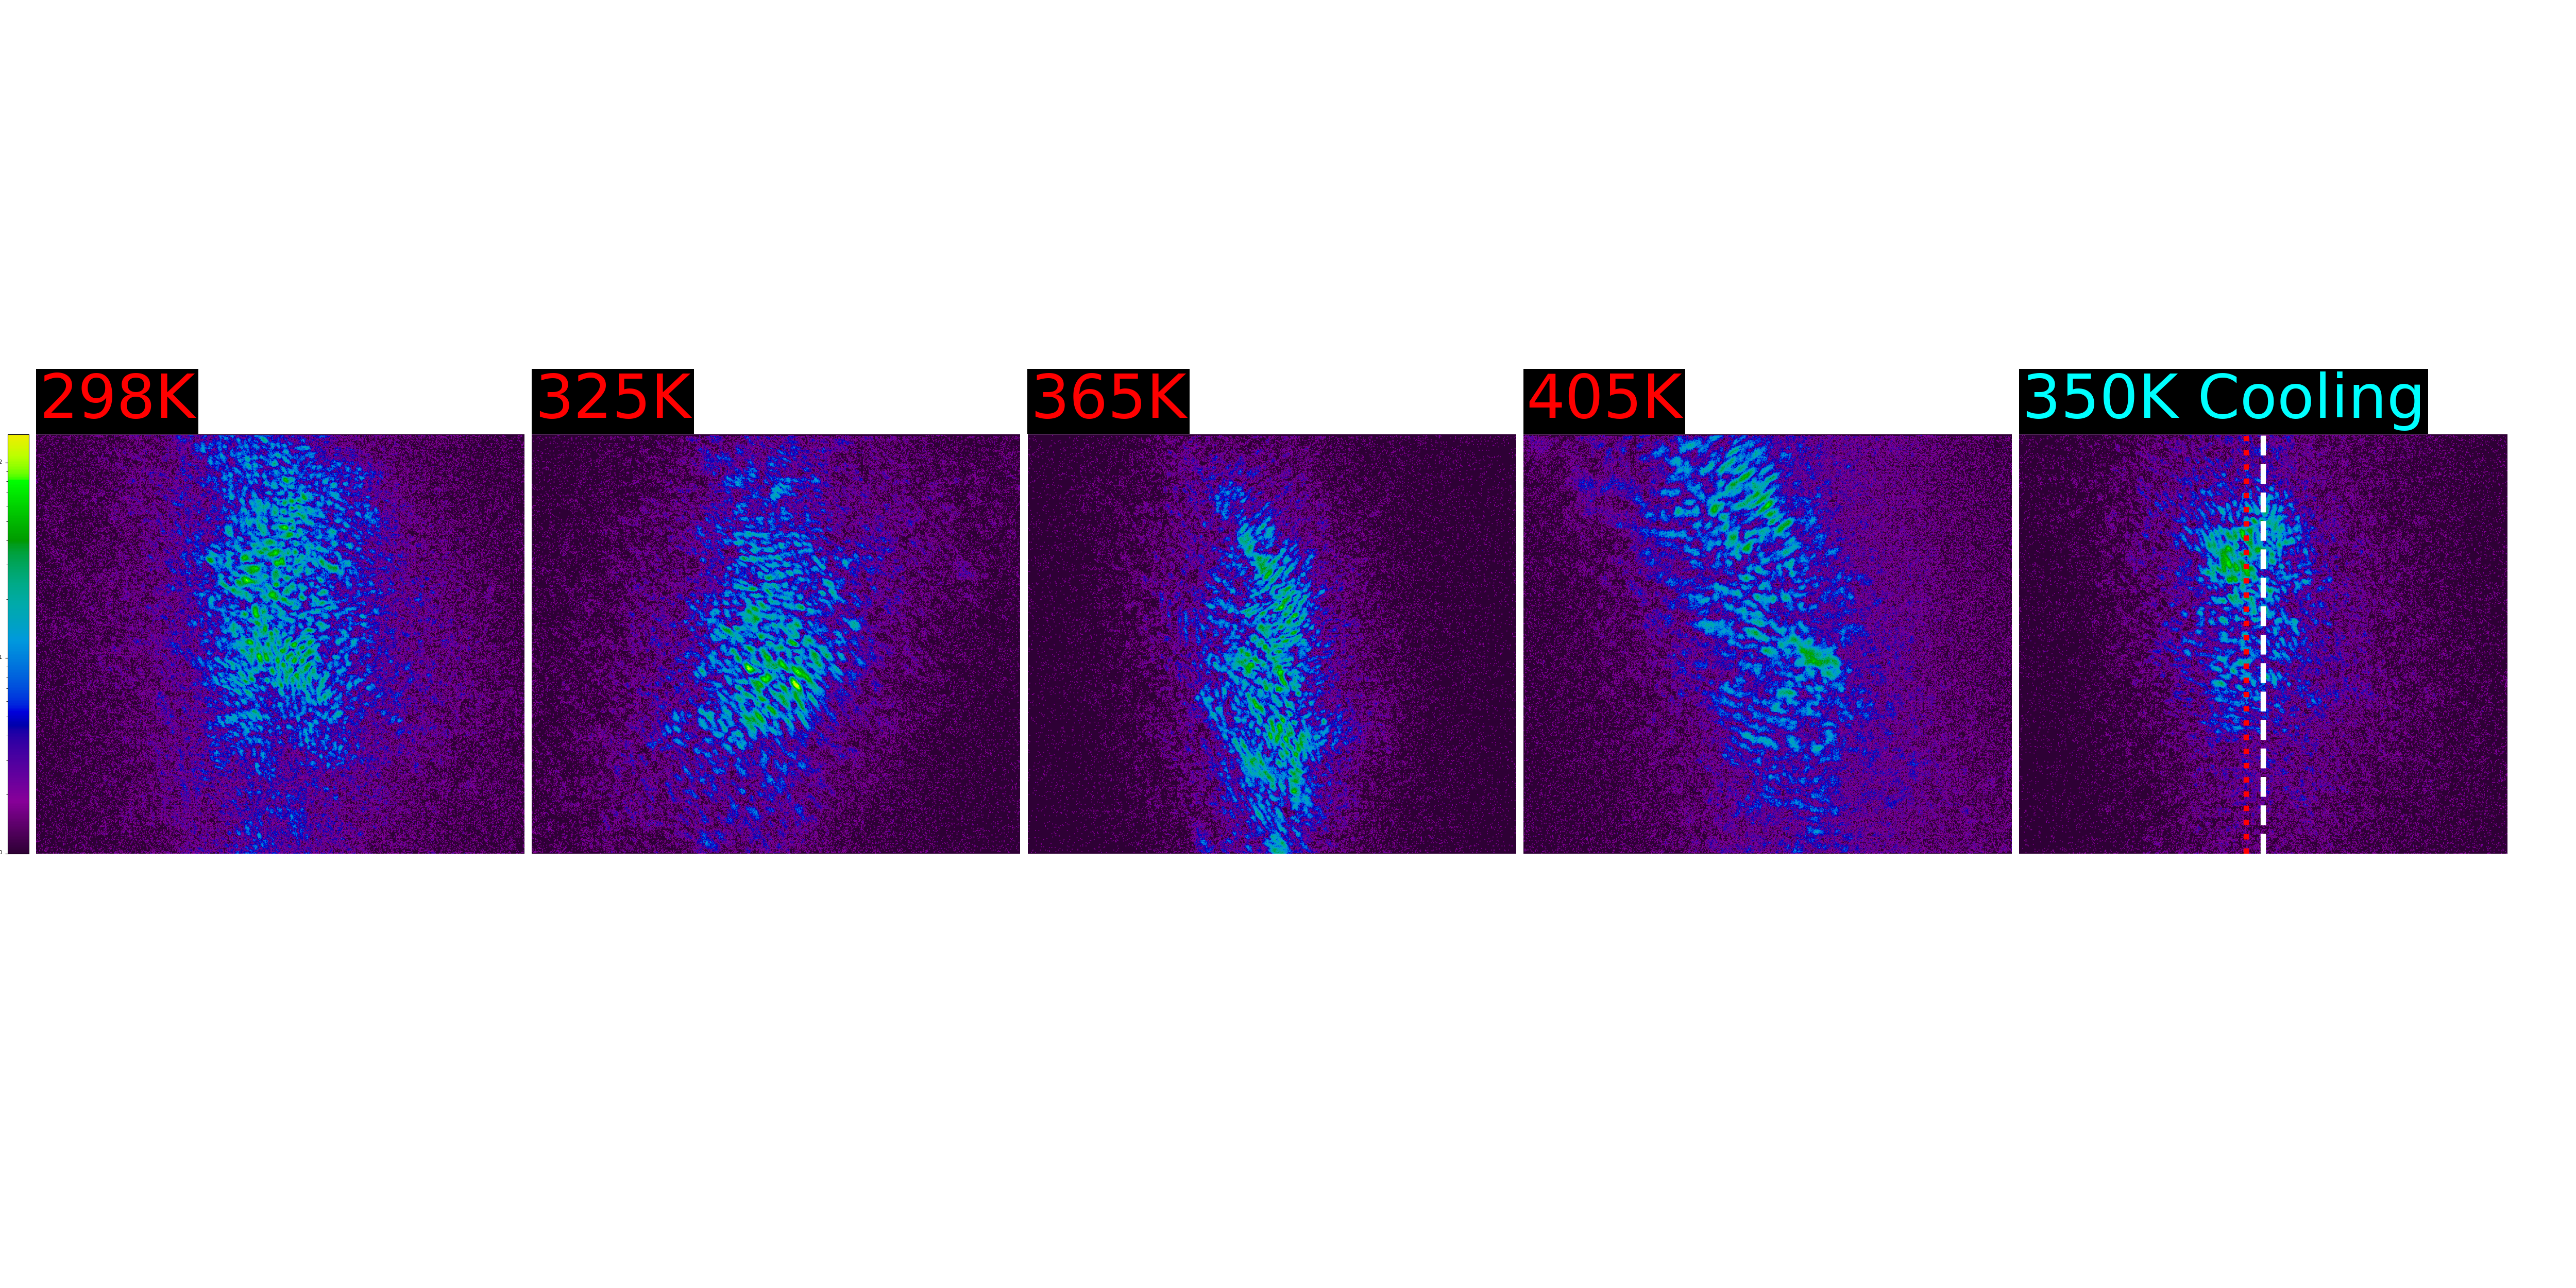

98.0
139.0
89.0
83.0
90.0


In [30]:
#tile_rois = np.array([[421,935],[351,865],[384,898],[466,980],[331,845],[476,990],[459,973],[488,1002]])
tile_rois = np.array([290,805])
#fig,ax = plt.subplots(1,temps.shape[0],figsize=(50,25))

fig,ax = plt.subplots(1,5,figsize=(50,25))

cen = DETS[0].shape[2]//2

j = 0
for i,im in enumerate(DETS):
    
    if temps[i] in [298,325,365,405,350]:
        if temps[i] != 350:
            Tlabel = f'{temps[i]}K'
            color_label = 'red'
        if temps[i] == 350:
            Tlabel = f'{temps[i]}K Cooling'
            color_label = 'cyan'


        IM = np.sum(im[:10,tile_rois[0]:tile_rois[1],int(cen-4*hSig):int(cen+4*hSig)],axis=0)
        print(np.max(IM))

        IMAGE = ax[j].imshow(IM+1,cmap=nipy_uc,norm=LogNorm(vmin=1, vmax=139))
        #IMAGE = ax[j].imshow(IM,cmap='nipy_spectral',vmin=0, vmax=10)
        #ax[i].imshow(np.sum(im[:40,:,:],axis=0)+1,cmap='nipy_spectral',norm=LogNorm(vmin=1, vmax=300))
        ax[j].axis('off')
        


        #ax[i].text(0.024, 0.978, Tlabel, color=color_label, fontsize=20,
        ax[j].text(0.006, 1.150, Tlabel, color=color_label, fontsize=85,
          ha='left', va='top', transform=ax[j].transAxes,
          bbox=dict(facecolor='black', alpha=1.0, edgecolor='none'))
        j+=1
        
        
ax[4].axvline(
    x=IM.shape[1]//2,
    color='white',
    linestyle='--',  # dot–dash–dash pattern
    linewidth=7.5
)

ax[4].axvline(
    x=IM.shape[1]//2-(HCENS[0,0]-HCENS[0,7]),
    color='red',
    linestyle=':',  # dot–dash–dash pattern
    linewidth=7.5
)
plt.tight_layout()

fig.colorbar(IMAGE, ax=ax, location='left', fraction=0.00838, pad=0.003)
fig.savefig(figure_path+"temp_series.pdf",format="pdf",bbox_inches="tight")


# $H = \S_{<ij>}$